<span style="color:pink; font-size:20px;">File to get plots for Ergotropic Changes vs Oscillator frequency and bath temperature gradients.</span>

In [ ]:
# Import necessary libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from state_gen import generate_state
from energy import global_ergo, local_ergo
from local_to import sho_ham, LTO_step, gibbs_states
from unitary import deg_unitary
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True)

def fmt(M): return np.array2string(M, precision=4, suppress_small=True, floatmode='fixed', max_line_width=80)

In [ ]:
# Default Parameters
beta_a=1.0
beta_b=0.8
bath_dim_a = bath_dim_b = 6
sys_dim_a = sys_dim_b = 3
omega_a = omega_b = 0.1
w1=0.1
w2=0.2

In [ ]:
def simulate_harmonic_pair(num_states=10):

    delta_Rg_list = []
    delta_Rl_list = []

    # ----- Baths -----
    gamma_a, gamma_b = gibbs_states( bath_dim_a, bath_dim_b, beta_a, beta_b, omega_a, omega_b)

    # ----- Hamiltonians -----
    Hs1 = sho_ham(sys_dim_a, w1)
    Hs2 = sho_ham(sys_dim_b, w2)
    Hb1 = sho_ham(bath_dim_a, omega_a)
    Hb2 = sho_ham(bath_dim_b, omega_b)

    # ----- Fixed unitary -----
    Ua = deg_unitary(Hs1, Hb1)
    Ub = deg_unitary(Hs2, Hb2)

    for _ in range(num_states):

        # ----- initial state -----
        rho = generate_state(sys_dim_a * sys_dim_b)

        # ---- initial ergotropy ----
        Rg0 = global_ergo(rho, sys_dim_a, sys_dim_b, w1, w2)
        Rl0 = local_ergo(rho, sys_dim_a, sys_dim_b, w1, w2)

        # ----- apply LTO -----
        sigma, _, _ = LTO_step(rho, gamma_a, gamma_b, Ua, Ub)

        # ---- final ergotropy ----
        Rg = global_ergo(sigma, sys_dim_a, sys_dim_b, w1, w2)
        Rl = local_ergo(sigma, sys_dim_a, sys_dim_b, w1, w2)

        # ---- store deltas ----
        delta_Rg_list.append(Rg - Rg0)
        delta_Rl_list.append(Rl - Rl0)

    # ---- return averaged values ----
    return np.mean(delta_Rg_list), np.mean(delta_Rl_list)

In [ ]:
# Functions to generate grids for w1, w2
def generate_w1_w2_grid(w_vals, beta_a_fixed, beta_b_fixed, num_states=100):

    global w1, w2, beta_a, beta_b

    beta_a = beta_a_fixed
    beta_b = beta_b_fixed

    W1, W2 = np.meshgrid(w_vals, w_vals)

    Z_Rg = np.zeros_like(W1)
    Z_Rl = np.zeros_like(W1)

    # Run simulations for each pair of (w1, w2) values
    for i in tqdm(range(len(w_vals))):
        for j in range(len(w_vals)):

            w1 = w_vals[i]
            w2 = w_vals[j]

            dRg, dRl = simulate_harmonic_pair(num_states=num_states)

            Z_Rg[i, j] = dRg
            Z_Rl[i, j] = dRl

    return W1, W2, Z_Rg, Z_Rl


# Functions to generate grids for beta_a, beta_b
def generate_beta1_beta2_grid(beta_vals, w1_fixed, w2_fixed, num_states=100):

    global w1, w2, beta_a, beta_b

    w1 = w1_fixed
    w2 = w2_fixed

    B1, B2 = np.meshgrid(beta_vals, beta_vals)

    Z_Rg = np.zeros_like(B1)
    Z_Rl = np.zeros_like(B1)

    # Run simulations for each pair of (beta_a, beta_b) values
    for i in tqdm(range(len(beta_vals))):
        for j in range(len(beta_vals)):

            beta_a = beta_vals[i]
            beta_b = beta_vals[j]

            dRg, dRl = simulate_harmonic_pair(num_states=num_states)

            Z_Rg[i, j] = dRg
            Z_Rl[i, j] = dRl

    return B1, B2, Z_Rg, Z_Rl


# Functions to generate grids for w and beta simultaneously ()
def generate_w_beta_grid(w_vals, beta_vals, num_states=100):

    global w1, w2, beta_a, beta_b

    W, B = np.meshgrid(w_vals, beta_vals)

    Z_Rg = np.zeros_like(W)
    Z_Rl = np.zeros_like(W)

    # Run simulations for each pair of (w, beta) values
    for i in tqdm(range(len(beta_vals))):
        for j in range(len(w_vals)):

            w = w_vals[j]
            beta = beta_vals[i]
            
            # set both w1, w2 to w and beta_a, beta_b to beta
            w1 = w2 = w
            beta_a = beta_b = beta

            dRg, dRl = simulate_harmonic_pair(num_states=num_states)

            Z_Rg[i, j] = dRg
            Z_Rl[i, j] = dRl

    return W, B, Z_Rg, Z_Rl

In [ ]:
def plot_harmonic_phase_diagrams(W1, W2, Z_Rg_w, Z_Rl_w, B1, B2, Z_Rg_b, Z_Rl_b, W, B, Z_Rg_wb, Z_Rl_wb,
    figsize=(16, 12),
    cmap='viridis',
    font_size=11,
    title_size=12,
    tick_size=9,
    dpi=120,
    save_path=None):

    plt.style.use('seaborn-v0_8-whitegrid')

    fig, axs = plt.subplots(3, 2, figsize=figsize, dpi=dpi)

    # ---- helper ----
    def plot_heat(ax, X, Y, Z, xlabel, ylabel, title):
        im = ax.pcolormesh(X, Y, Z, shading='auto', cmap=cmap)
        ax.set_xlabel(xlabel, fontsize=font_size)
        ax.set_ylabel(ylabel, fontsize=font_size)
        ax.set_title(title, fontsize=title_size)
        ax.tick_params(labelsize=tick_size)
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=tick_size-1)

    # ============================================================
    # CASE 1 — w1 vs w2
    # ============================================================

    plot_heat(axs[0,0], W1, W2, Z_Rg_w, r"$\omega_1$", r"$\omega_2$", r"$\Delta R_g$ vs $(\omega_1,\omega_2)$")

    plot_heat(axs[0,1], W1, W2, Z_Rl_w, r"$\omega_1$", r"$\omega_2$", r"$\Delta R_l$ vs $(\omega_1,\omega_2)$")

    # ============================================================
    # CASE 2 — beta1 vs beta2
    # ============================================================

    plot_heat(axs[1,0], B1, B2, Z_Rg_b, r"$\beta_1$", r"$\beta_2$", r"$\Delta R_g$ vs $(\beta_1,\beta_2)$")

    plot_heat(axs[1,1], B1, B2, Z_Rl_b, r"$\beta_1$", r"$\beta_2$", r"$\Delta R_l$ vs $(\beta_1,\beta_2)$")

    # ============================================================
    # CASE 3 — w vs beta
    # ============================================================

    plot_heat(axs[2,0], W, B, Z_Rg_wb, r"$\omega$", r"$\beta$", r"$\Delta R_g$ vs $(\omega,\beta)$")

    plot_heat(axs[2,1], W, B, Z_Rl_wb, r"$\omega$", r"$\beta$", r"$\Delta R_l$ vs $(\omega,\beta)$")

    # ---- layout ----
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Saved → {save_path}")

    plt.show()


In [ ]:
# Initialize parameters for harmonic oscillator simulation

# Inverse temperatures and dimensions
beta_a=1.0
beta_b=0.8
bath_dim_a = bath_dim_b = 10
sys_dim_a = sys_dim_b = 4

# Hamiltonian parameters
omega_a = omega_b = 0.1
w1=0.1
w2=0.2

In [ ]:
# Generate grids for w1 vs w2, beta1 vs beta2, and w vs beta
w_vals = np.linspace(0.01, 0.2, 20)
beta_vals = np.linspace(0.1, 2.0, 20)

W1, W2, Z_Rg_w, Z_Rl_w = generate_w1_w2_grid(w_vals, beta_a_fixed=beta_a, beta_b_fixed=beta_b, num_states=1)
B1, B2, Z_Rg_b, Z_Rl_b = generate_beta1_beta2_grid(beta_vals, w1_fixed=w1, w2_fixed=w2, num_states=1)
W, B, Z_Rg_wb, Z_Rl_wb = generate_w_beta_grid(w_vals, beta_vals, num_states=1)

  0%|          | 0/20 [00:00<?, ?it/s]

Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 10]', 'E=0.2000: [2, 11, 20]', 'E=0.3000: [3, 12, 21, 30]', 'E=0.4000: [4, 13, 22, 31]', 'E=0.5000: [5, 14, 23, 32]', 'E=0.6000: [6, 15, 24, 33]', 'E=0.7000: [7, 16, 25, 34]', 'E=0.8000: [8, 17, 26, 35]', 'E=0.9000: [9, 18, 27, 36]', 'E=1.0000: [19, 28, 37]', 'E=1.1000: [29, 38]']
Degenerate blocks: ['E=0.3000: [3, 20]', 'E=0.4000: [4, 21]', 'E=0.5000: [5, 22]', 'E=0.6000: [6, 23]', 'E=0.7000: [7, 24]', 'E=0.8000: [8, 25]', 'E=0.9000: [9, 26]', 'E=0.4500: [13, 30]', 'E=0.5500: [14, 31]', 'E=0.6500: [15, 32]', 'E=0.7500: [16, 33]', 'E=0.8500: [17, 34]',

  5%|▌         | 1/20 [00:16<05:21, 16.93s/it]

Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 10]', 'E=0.2000: [2, 11, 20]', 'E=0.3000: [3, 12, 21, 30]', 'E=0.4000: [4, 13, 22, 31]', 'E=0.5000: [5, 14, 23, 32]', 'E=0.6000: [6, 15, 24, 33]', 'E=0.7000: [7, 16, 25, 34]', 'E=0.8000: [8, 17, 26, 35]', 'E=0.9000: [9, 18, 27, 36]', 'E=1.0000: [19, 28, 37]', 'E=1.1000: [29, 38]']
Degenerate blocks: ['E=0.3000: [3, 20]', 'E=0.4000: [4, 21]', 'E=0.5000: [5, 22]', 'E=0.6000: [6, 23]', 'E=0.7000: [7, 24]', 'E=0.8000: [8, 25]', 'E=0.9000: [9, 26]', 'E=0.4500: [13, 30]', 'E=0.5500: [14, 31]', 'E=0.6500: [15, 32]', 'E=0.7500: [16, 33]', 'E=0.8500: [17, 34]',

 10%|█         | 2/20 [00:33<05:05, 16.98s/it]

...

 90%|█████████ | 18/20 [05:20<00:35, 17.67s/it]

Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 10]', 'E=0.2000: [2, 11, 20]', 'E=0.3000: [3, 12, 21, 30]', 'E=0.4000: [4, 13, 22, 31]', 'E=0.5000: [5, 14, 23, 32]', 'E=0.6000: [6, 15, 24, 33]', 'E=0

 95%|█████████▌| 19/20 [05:37<00:17, 17.65s/it]

Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 20]', 'E=0.2000: [2, 21]', 'E=0.3000: [3, 22]', 'E=0.4000: [4, 23]', 'E=0.5000: [5, 24]', 'E=0.6000: [6, 25]', 'E=0.7000: [7, 26]', 'E=0.8000: [8, 27]', 'E=0.9000: [9, 28]', 'E=0.1500: [11, 30]', 'E=0.2500: [12, 31]', 'E=0.3500: [13, 32]', 'E=0.4500: [14, 33]', 'E=0.5500: [15, 34]', 'E=0.6500: [16, 35]', 'E=0.7500: [17, 36]', 'E=0.8500: [18, 37]', 'E=0.9500: [19, 38]']
Degenerate blocks: ['E=0.1000: [1, 10]', 'E=0.2000: [2, 11, 20]', 'E=0.3000: [3, 12, 21, 30]', 'E=0.4000: [4, 13, 22, 31]', 'E=0.5000: [5, 14, 23, 32]', 'E=0.6000: [6, 15, 24, 33]', 'E=0

100%|██████████| 20/20 [05:55<00:00, 17.78s/it]


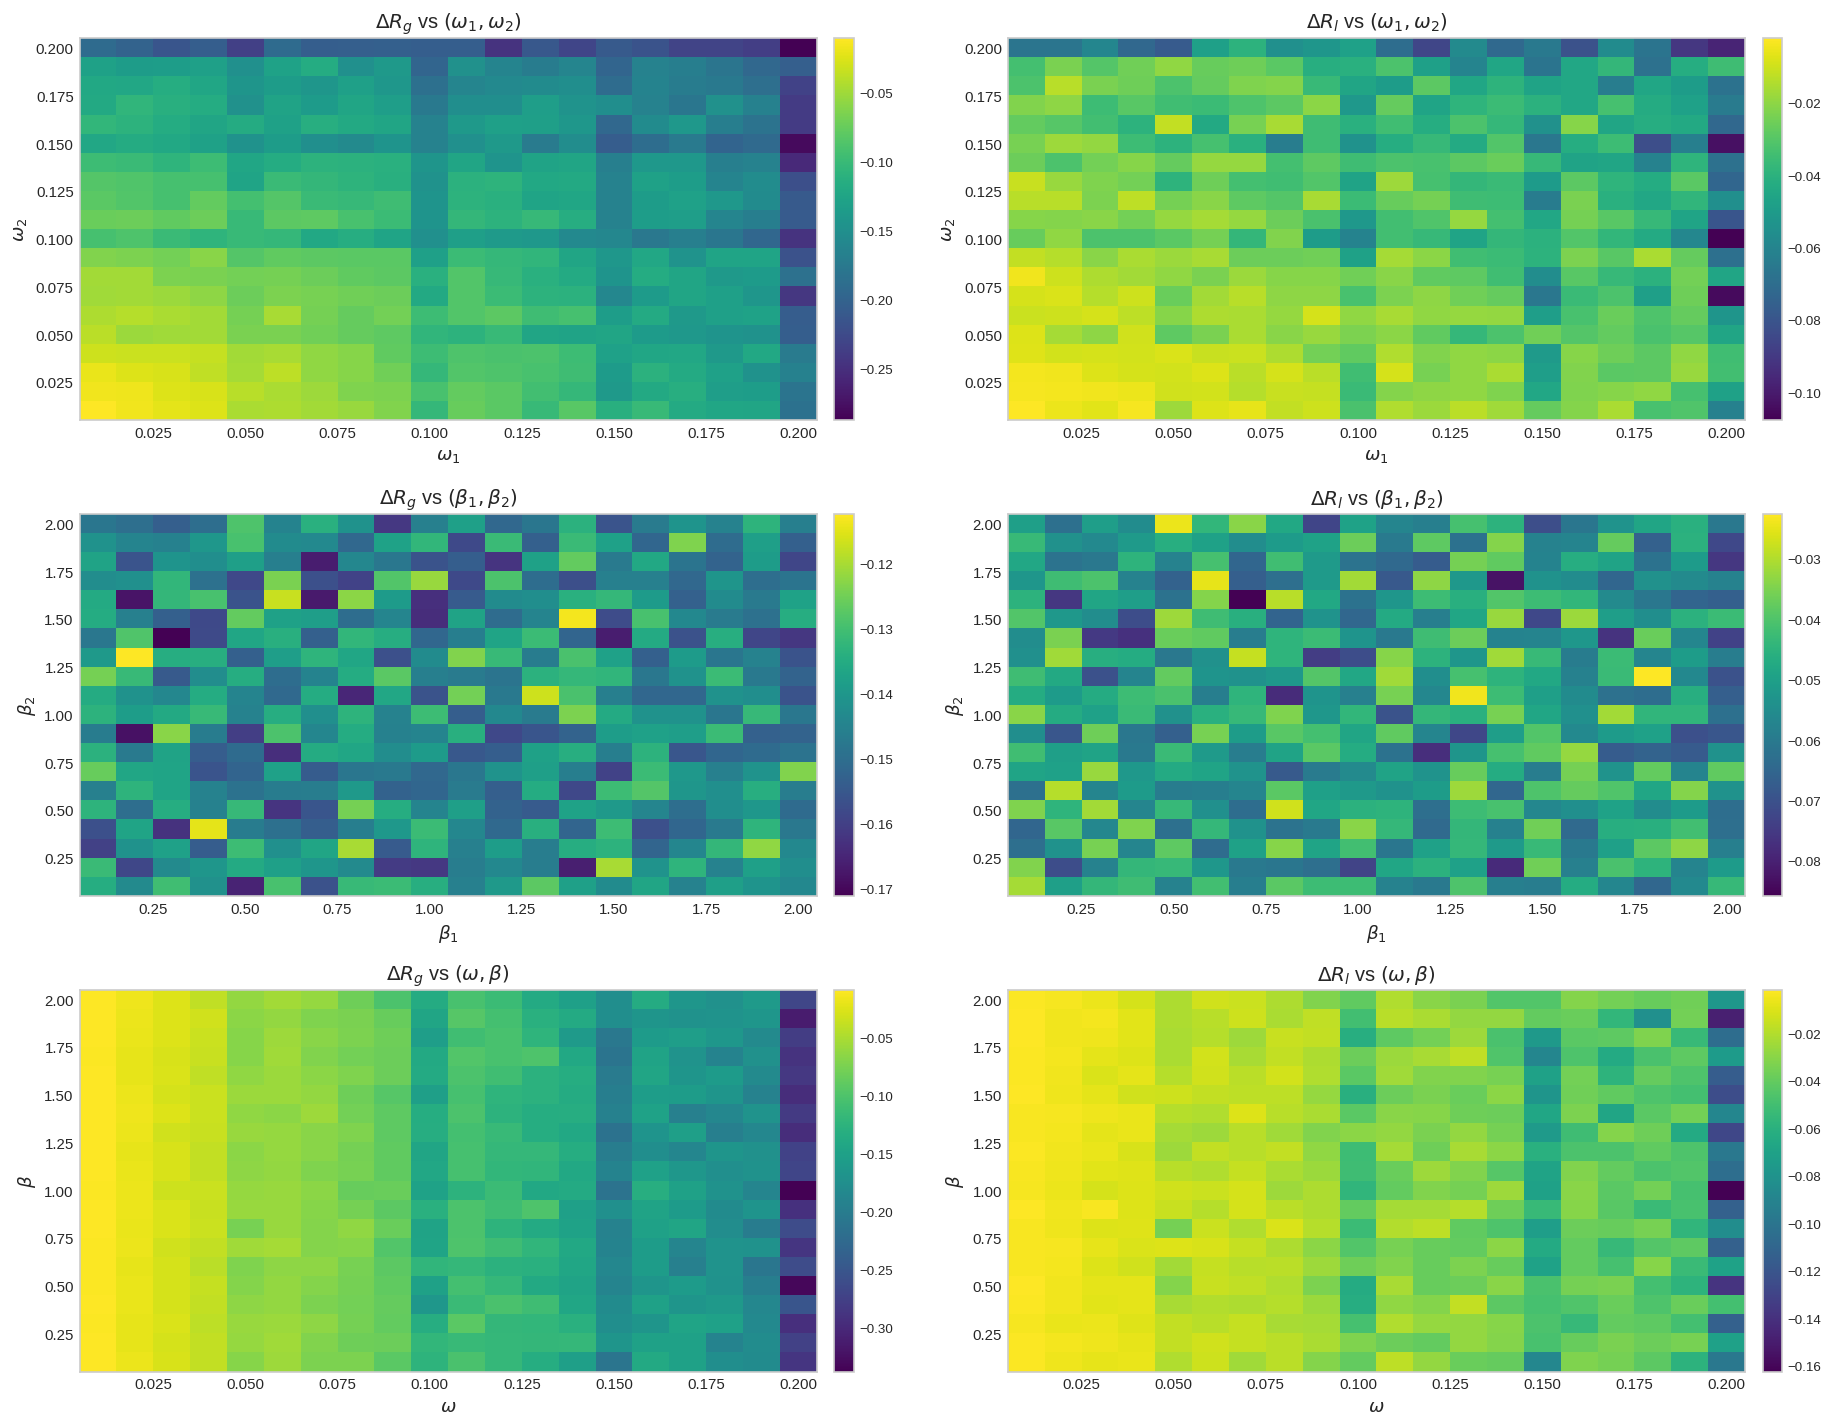

In [ ]:
# Plot the phase diagrams
plot_harmonic_phase_diagrams(W1, W2, Z_Rg_w, Z_Rl_w, B1, B2, Z_Rg_b, Z_Rl_b, W, B, Z_Rg_wb, Z_Rl_wb)